In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import json
from munch import Munch
import itertools
from collections import defaultdict
import random
import copy
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import importlib
import time

from dna_algorithms import create_cst_params, convertTensor_list, simulation, Viterbi_torch_list, \
satTime_torch_list, ffbs_torch_list, variable_length_sampling, satprob_torch_list, baum_welch_unconstrained, generalized_em_constrained, sample_constrained_fixed_length, randomize_hmm_like
from conin.mediation_variables.ICML26_code.mv_Viterbi import mv_Viterbi

### Create the HMM

In [3]:
hidden_states = ['pro','ex1','ex2','int','dis','enh', 'end']
emit_states = ['A','T', 'C', 'G', 'N']
hidden_size, emit_size = len(hidden_states), len(emit_states)

hmm_mat = np.array([
    [.6,.1,.1,.2,0,0,0], #promoter
    [0,.4,.3,.2,.1,0,0], #exon1
    [.0,.3,.4,0,.2,.1,0], #exon2
    [.1,.1,.1,.4,0,.1,.2], #intron
    [0,1/3, 1/3, 0,1/3,0,0], #disease
    [0,.25,.25,.25,0,.25,0], #enhancer
    [0,0,0,0,0,0,1] #end of sequence
])

emit_mat = np.array([ #
    [.1,.1,.4,.4,0], #CG rich promoter
    [.1,.1,.7,.1,0], #Exon 1 favors C
    [.7,.1,.1,.1,0], #Exon 2 favors A
    [.25,.25,.25,.25,0], #Intron 
    [.5,0,.5,0,0], #Disease favors AC
    [.4,.4,.1,.1,0], #AT rich enhancer
    [0,0,0,0,1] #end has no nucleotide emissions
])

init_vec = np.array(
    [.5,0,0,.5,0,0, 0]
)

hmm_transition = {}
for i in range(hidden_size):
    for j in range(hidden_size):
        hmm_transition[hidden_states[i],hidden_states[j]] = hmm_mat[i,j].item()

hmm_emit = {}
for i in range(hidden_size):
    for j in range(emit_size):
        hmm_emit[hidden_states[i],emit_states[j]] = emit_mat[i,j].item()
        
hmm_startprob = {}
for i in range(hidden_size):
    hmm_startprob[hidden_states[i]] = init_vec[i]

end_hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))

In [4]:
# hidden_states = ['pro','ex1','ex2','int','dis','enh', 'end']
# emit_states = ['A','T', 'C', 'G']
# hidden_size, emit_size = len(hidden_states), len(emit_states)

# hmm_mat = np.array([
#     [.6,.1,.1,.2,0,0,0], #promoter
#     [0,.4,.3,.2,.1,0,0], #exon1
#     [.0,.3,.4,0,.2,.1,0], #exon2
#     [.1,.1,.1,.4,0,.1,.2], #intron
#     [0,1/3, 1/3, 0,1/3,0,0], #disease
#     [0,.25,.25,.25,0,.25,0], #enhancer
#     [0,0,0,0,0,0,1] #end of sequence
# ])

# emit_mat = np.array([ #
#     [.1,.1,.4,.4], #CG rich promoter
#     [.1,.1,.7,.1], #Exon 1 favors C
#     [.7,.1,.1,.1], #Exon 2 favors A
#     [.25,.25,.25,.25], #Intron 
#     [.5,0,.5,0], #Disease favors AC
#     [.4,.4,.1,.1], #AT rich enhancer
#     [.25,.25,.25,.25] #end has no nucleotide emissions
# ])

# init_vec = np.array(
#     [.5,0,0,.5,0,0, 0]
# )

# hmm_transition = {}
# for i in range(hidden_size):
#     for j in range(hidden_size):
#         hmm_transition[hidden_states[i],hidden_states[j]] = hmm_mat[i,j].item()

# hmm_emit = {}
# for i in range(hidden_size):
#     for j in range(emit_size):
#         hmm_emit[hidden_states[i],emit_states[j]] = emit_mat[i,j].item()
        
# hmm_startprob = {}
# for i in range(hidden_size):
#     hmm_startprob[hidden_states[i]] = init_vec[i]

# hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))

### Stay > = 3

In [5]:
def update_fun(k , r, r_past):
    '''
    r = hidden_states x [1,2,3, 4]
    '''
    prev, count = r_past #r is a tuple
    if k == prev:
        new_count = min(count + 1 , 3)
        # new_count = min(count + 1 , 4)
    else:
        new_count = 1
        
    # if ((count == 3 or k == prev) and r == (k, new_count)) or k == 'end':
    if (count == 3 or k == prev) and r == (k, new_count):
        return True
    else:
        return False

def init_fun(k, r):
    '''
    initial "prob" of r = (m1,m2) from k. is just indicator
    '''

    return r == (k,1)

    
def eval_fun(k, r):
    return 1

m_states = list(itertools.product(hidden_states, list(range(1,3+1))))

stay_cst = Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states)

In [6]:
update_fun('enh',('enh',1), ('pro',3))

True

In [7]:
test_params = create_cst_params(stay_cst, hidden_states)

print(test_params[0].sum(axis = 1),test_params[1].sum(axis = 1),test_params[2].sum(axis = 1))

tensor([1., 1., 1., 1., 1., 1., 1.]) tensor([21., 21., 21., 21., 21., 21., 21.]) tensor([[1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1.],
        [0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1.],
        [0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1.],
        [0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1.,
         0., 0., 1.],
        [0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1.,
         0., 0., 1.],
        [0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1.,
         0., 0., 1.],
        [0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
         1., 1., 1.]])


### Promoter Must Occur in First 10

In [8]:
def update_fun(k , r, r_past):
    '''
    r = Boolean
    tracks if 'pro' has occured yet or not
    '''        

    return r == (r_past or (k == 'pro')) 

def init_fun(k, r):

    return r == (k == 'pro')

def eval_fun(k,r):
    return 1

m_states = [True,False]

promoter_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

In [9]:
test_params = create_cst_params(promoter_cst, hidden_states)

print(test_params[0].sum(axis = 1),test_params[1].sum(axis = 1),test_params[2].sum(axis = 1))

tensor([1., 1., 1., 1., 1., 1., 1.]) tensor([2., 2., 2., 2., 2., 2., 2.]) tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])


## Visit Dis Exactly Once 

In [10]:
def update_fun(k , r, r_past):
    '''
    r =  [True,False] x [0,1,2]
    r[0] is True if previoius state was NOT dis.
    counts number of entries into dis (ie. number of dis regions)
    '''
    prev, count = r_past

    if prev and k == 'dis':
        count = min(count + 1, 2)    
    
    return r == (k != 'dis',count) 

def init_fun(k, r):

    if k == 'dis':
        return r == (False,1)
    else:
        return r == (True,0)

def eval_fun(k,r):
    return r[1] == 1 #must be exactly 1.

m_states = list(itertools.product([True,False], list(range(3))))


disvisit_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

### Promoter < Disease < Enhancer

In [11]:
def update_fun(k , r, r_past):
    '''
    r = Boolean_pro x Bool_dis x Bool_enh
    trcks that they occur in sequence
    '''
    occur_pro, occur_dis, occur_enh = r_past
    consist = True
    
    pro_new = (k == 'pro' or occur_pro)
    dis_new = (k == 'dis' or occur_dis)
    enh_new = (k == 'enh' or occur_enh)

    if k == 'dis': #if at anytime dis occurs before pro, that sequence is zero'd out.
        consist = pro_new

    if k == 'enh':
        consist = dis_new 

    return (r == (pro_new, dis_new,enh_new)) and consist

def init_fun(k, r):

    return r == ( k == 'pro', k == 'dis', k == 'enh')

def eval_fun(k,r):
    # return 1 

    return r[2] == True #ensures that enhancer is in the sequence

m_states = list(itertools.product([True, False], repeat=3))

pde_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))



In [12]:
def update_fun(k , r, r_past):
    '''
    r = Boolean_pro x Bool_dis x Bool_enh
    trcks that they occur in sequence
    '''
    occur_pro, occur_enh = r_past
    consist = True
    
    pro_new = (k == 'pro' or occur_pro)
    enh_new = (k == 'enh' or occur_enh)

    if k == 'enh':
        consist = pro_new 

    return (r == (pro_new,enh_new)) and consist

def init_fun(k, r):

    return r == ( k == 'pro', k == 'enh')

def eval_fun(k,r):
    return 1 #ensures that enhancer is in the sequence

    # return r[1] == True #ensures that enhancer is in the sequence

m_states = list(itertools.product([True, False], repeat=2))

pe_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))



# Hitting Constraint for Dis

In [13]:
def update_fun(k , r, r_past):
    '''
    r =  [True,False]
    r is a Boolean that tracks if dis has occured
    '''
        
    return r == (r_past or k == 'dis') 

def init_fun(k, r):

    return r == (k == 'dis')

def eval_fun(k,r):
    return r == True #dis has occured

m_states = [True,False]


hitdis_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

# Hitting Constraint for End

In [14]:
def update_fun(k , r, r_past):
    '''
    r =  [True,False]
    r is a Boolean that tracks if dis has occured
    '''
        
    return r == (r_past or k == 'end') 

def init_fun(k, r):

    return r == (k == 'end')

def eval_fun(k,r):
    return r == True

m_states = [True,False]


hitend_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

# Only Last State is End

In [15]:
def update_fun(k , r, r_past):
    '''
    r =  True
    r is a dummy var needed for bookeeping in tensor operations
    '''
    counter = r_past
    if k == 'end':
        counter += 1
    return r == min(counter, 2)
    
def init_fun(k, r):

    return r == int(k == 'end')

def eval_fun(k,r):
    return k == 'end' and (r < 2) #have not encountered 'end' before

m_states = [0,1,2]


end_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

### Visit Dis at most Once

In [16]:
def update_fun(k , r, r_past):
    '''
    r =  [True,False] x [0,1,2]
    r[0] is True if previoius state was NOT dis.
    counts number of entries into dis (ie. number of dis regions)
    '''
    prev, count = r_past

    if prev and k == 'dis':
        count = min(count + 1, 2)    
    
    return r == (k != 'dis',count) 

def init_fun(k, r):

    if k == 'dis':
        return r == (False,1)
    else:
        return r == (True,0)

def eval_fun(k,r):
    return r[1] != 2 #must be 0 or 1

m_states = list(itertools.product([True,False], list(range(3))))



disvisit_atmost_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))

# Dummy Constraint

In [17]:
def update_fun(k, r, r_past):
    return r == True

def init_fun(k, r):

    return r == True

def eval_fun(k, r):
    return 1

m_states = [True,False]

dummy_cst = copy.deepcopy(Munch(update_fun = update_fun, init_fun = init_fun, eval_fun = eval_fun, m_states = m_states))


In [18]:
dummy_list = [dummy_cst]

In [19]:
# _, dummy_params = convertTensor_list(hmm, dummy_list, dtype = torch.float16, device = 'cpu', hmm_params = None, return_ix = False)

# Set Seed

In [20]:
seed = 23

rng = np.random.default_rng(seed)
state_list, emit_list = simulation(end_hmm, min_time = 30, stay=3, pro_before=10, ix_list=None, max_attempts=1000, rng = rng)

# Experiments: Constrained Inference

In [21]:
cst_list = [promoter_cst,stay_cst,disvisit_cst, pde_cst]

In [22]:
dummy_list = [dummy_cst]

In [23]:
opt_state_list, opt_augstateix_list = Viterbi_torch_list(end_hmm, cst_list, emit_list, pro_before = 10, dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)

In [24]:
unc_state_list = mv_Viterbi(emit_list, end_hmm, cst = None)

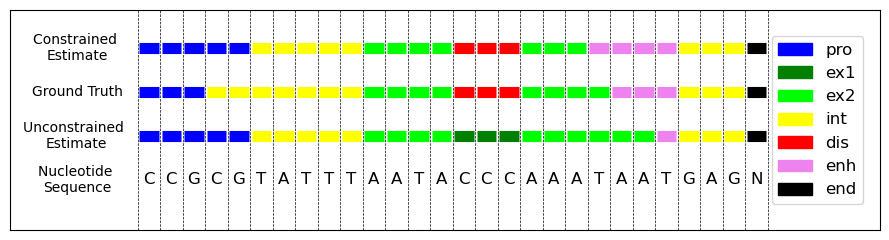

In [25]:

# Define the common list and its corresponding colors
common_list = ['pro', 'ex1', 'ex2', 'int', 'dis', 'enh', 'end']
colors = {
    'pro': 'blue',
    'ex1': 'green',
    'ex2': 'lime',
    'int': 'yellow',
    'dis': 'red',
    'enh': 'violet',
    'end' : 'black'
}

# Example lists with length 30
# Function to plot a single list as a line with colored segments
tick_length = .75

# def plot_colored_line(ax, data, y_position):
#     x_start = 0
#     for word in data:
#         x_end = x_start + tick_length  # Each word occupies a segment of length 1
#         ax.plot([x_start, x_end], [y_position, y_position], color=colors[word], linewidth=8)
#         x_start = x_end

def plot_colored_line(ax, data, y_position, dash = False):
    x_start = 3.25
    bleed_offset = 0.05  # Adjust this value to account for bleeding

    for word in data:
        x_end = x_start + tick_length  # Each word occupies a segment of length tick_length
        
        # Draw the horizontal colored segment
        ax.plot([x_start + bleed_offset, x_end - bleed_offset], [y_position, y_position], 
                color=colors[word], linewidth=8, solid_capstyle='butt')  # Prevent bleeding
        if dash:
            # Add dashed vertical line at the start of the segment (spanning the entire plot)
            ax.plot([x_start, x_start], [0, 4], color='black', linewidth=0.5, linestyle='--')  # Dashed vertical line
        
        x_start = x_end
    if dash:
    # Add a dashed vertical line at the end of the last segment (spanning the entire plot)
        ax.plot([x_start, x_start], [0, 4], color='black', linewidth=0.5, linestyle='--')  # Dashed vertical line# Function to plot letters on the fourth line
def plot_letters(ax, data, y_position):
    x_start = 3.25
    for letter in data:
        ax.text(x_start + tick_length / 2, y_position, letter,
                fontsize=12, ha='center', va='center')  # Center the letter in the segment
        x_start += tick_length


# Create the plot
fig, ax = plt.subplots(figsize=(9, 2.5))  # Adjusted figure size for compression

offset = .8
vert = .7
# Plot each list as a line stacked vertically
plot_colored_line(ax, opt_state_list, offset + 3*vert, dash = True) 
plot_colored_line(ax, state_list, offset +2*vert)  
plot_colored_line(ax, unc_state_list, offset  + vert) 

plot_letters(ax, emit_list, offset )  # Line 4 at y=0

fontsize = 10

ax.text(1.25, offset + 3*vert, 'Constrained \nEstimate', va='center', fontsize=fontsize, zorder=8, ha = 'center')
ax.text(1.25, offset + 2*vert, 'Ground Truth', va='center', fontsize=fontsize, zorder=8, ha = 'center')
ax.text(1.2, offset + vert, 'Unconstrained \nEstimate', va='center', fontsize=fontsize, zorder=8, ha = 'center')
ax.text(1.25, offset, 'Nucleotide \nSequence', va='center', fontsize=fontsize, zorder=8, ha = 'center')
# Add legend
legend_patches = [mpatches.Patch(color=color, label=word) for word, color in colors.items()]
ax.legend(handles=legend_patches, loc='center right', title='',bbox_to_anchor=(.99, .5), fontsize=12)

# Adjust plot limits and aesthetics
ax.set_xlim(-1, len(emit_list)) 
ax.set_ylim(0, 3)
ax.set_yticks([]) 
ax.set_xticks([]) 
# ax.set_title('Functional Region Inference: Constrained vs. Unconstrained', fontsize=12)
ax.grid(False)

ax.set_ylim(0, 3.5)  # Reduce the upper limit from 4 to 3.5
# Show the plot
plt.tight_layout()

plt.savefig('dna_inference.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


# Satisfaction Time Algorithm

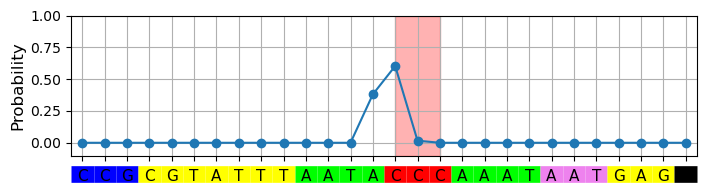

In [26]:
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches

sat_cst_list = [promoter_cst, stay_cst, pde_cst, hitdis_cst]
sat_probs, alpha, beta = satTime_torch_list(
    end_hmm,
    sat_cst_list,
    emit_list,
    pro_before=10,
    dtype=torch.float32,
    device='cuda:0',
    debug=False
)

common_list = ['pro', 'ex1', 'ex2', 'int', 'dis', 'enh', 'end']
colors = {
    'pro': 'blue',
    'ex1': 'green',
    'ex2': 'lime',
    'int': 'yellow',
    'dis': 'red',
    'enh': 'violet',
    'end': 'black'
}

fig, ax = plt.subplots(figsize=(9, 2.5))
indices = list(range(len(state_list)))

norm_probs = sat_probs / sat_probs.sum()
ax.plot(indices, norm_probs.tolist(), marker='o')

# Use data coordinates in x, axes coordinates in y
trans = blended_transform_factory(ax.transData, ax.transAxes)

tick_length = 1
state_y = -0.13
nuc_y = -0.15

# Draw colored hidden-state bar outside the plot
x_start = -0.5
for i, state in enumerate(state_list):
    x_end = x_start + tick_length

    ax.plot(
        [x_start, x_end],
        [state_y, state_y],
        color=colors[state],
        linewidth=12,
        solid_capstyle='butt',
        clip_on=False,
        transform=trans
    )

    x_start = x_end

# Draw nucleotide sequence outside the plot
for i, nuc in enumerate(emit_list):
    ax.text(
        i,
        nuc_y,
        nuc,
        fontsize=11,
        ha='center',
        va='center',
        clip_on=False,
        transform=trans
    )

# Axis labels
# ax.set_xlabel('Ground Truth Functional Regions', fontsize=12, labelpad=30)
ax.set_ylabel('Probability', fontsize=12)

# Hide x tick labels since sequence shown below
ax.set_xticks(indices)
ax.set_xticklabels([''] * len(indices))
ax.set_xlim(-0.5, len(state_list) - 0.5)
ax.set_ylim([-.1,1])
# Highlight dis region
start = None
end = None
for ix, state in enumerate(state_list):
    if state == "dis":
        if start is None:
            start = ix
        end = ix

if start is not None and end is not None:
    ax.axvspan(start, end, color='red', alpha=0.3)

# # Legend outside plot
# legend_patches = [mpatches.Patch(color=color, label=word) for word, color in colors.items()]
# ax.legend(
#     handles=legend_patches,
#     loc='center left',
#     bbox_to_anchor=(1.02, 0.5),
#     fontsize=10,
#     borderaxespad=0.
# )

ax.grid(True)

# Leave room at bottom for outside annotations and at right for legend
plt.subplots_adjust(bottom=0.32, right=0.82)
plt.savefig('dna_satTime.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

# Fixed Length Sampling

In [27]:
sampled_path = ffbs_torch_list(end_hmm, cst_list, emit_list, pro_before = 10, dtype = torch.float32,  device = 'cuda:0', debug = False)

# Variable Length Sampling

In [28]:
timecst_list = cst_list + [hitend_cst]
samplecst_list = cst_list + [end_cst]

In [29]:
emit_dict= {}
prob_include = 1/3
for i in range(len(emit_list) - 1):
    flip = np.random.uniform()
    if flip < prob_include:
        emit_dict[i] = emit_list[i]

In [30]:
# State colors
colors = {
    'pro': 'blue',
    'ex1': 'green',
    'ex2': 'lime',
    'int': 'yellow',
    'dis': 'red',
    'enh': 'violet',
    'end': 'black'
}

tick_length = 0.75


def plot_colored_line(ax, seq, y, colors, y_min, y_max, tick_length=0.75):
    bleed = 0.05

    for i, state in enumerate(seq):
        x0 = i * tick_length
        x1 = x0 + tick_length

        # colored horizontal segment
        ax.plot(
            [x0 + bleed, x1 - bleed],
            [y, y],
            color=colors[state],
            linewidth=8,
            solid_capstyle='butt'
        )

        # dashed vertical boundary at left edge of segment
        ax.plot(
            [x0, x0],
            [y_min, y_max],
            color='black',
            linewidth=0.5,
            linestyle='--'
        )

    # dashed vertical boundary at right edge of final segment
    if len(seq) > 0:
        x_end = len(seq) * tick_length
        ax.plot(
            [x_end, x_end],
            [y_min, y_max],
            color='black',
            linewidth=0.5,
            linestyle='--'
        )


def plot_partial_observations(ax, obs_dict, y, tick_length=0.75):
    for idx in sorted(obs_dict):
        x = idx * tick_length + tick_length / 2
        ax.text(x, y, obs_dict[idx], ha='center', va='center', fontsize=12)


def plot_sequences(sequences, obs_dict, colors, tick_length=0.75, figsize=(10, 3.5)):
    """
    sequences: list of sequences, where each sequence is a list of state strings
    obs_dict: dict like {10: 'C', 15: 'A'}
    """
    fig, ax = plt.subplots(figsize=figsize)

    offset = 0.4
    vert = 1
    n = len(sequences)

    y_min = 0
    y_max = offset + (n + 1.0) * vert

    # plot each sequence
    for j, seq in enumerate(sequences):
        y = offset + (n - j) * vert
        plot_colored_line(ax, seq, y, colors, y_min, y_max, tick_length=tick_length)

    # plot observed nucleotides on bottom row
    plot_partial_observations(ax, obs_dict, offset, tick_length=tick_length)

    # # legend outside the plot
    # legend_patches = [mpatches.Patch(color=c, label=s) for s, c in colors.items()]
    # ax.legend(
    #     handles=legend_patches,
    #     loc='center left',
    #     bbox_to_anchor=(1.02, 0.5),
    #     fontsize=10,
    #     borderaxespad=0.
    # )

    # axis limits
    max_seq_len = max((len(seq) for seq in sequences), default=0)
    max_obs_idx = max(obs_dict.keys(), default=-1) + 1
    max_len = max(max_seq_len, max_obs_idx)

    ax.set_xlim(-0.5, max_len * tick_length + 0.5)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    # ax.set_title('Posterior Sampling of Constrained DNA Sequences', fontsize=  18)
    # ax.set_xlabel('Partially Observed Nucelotide Sequence')

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.savefig('dna_sampling.pdf', format='pdf', dpi=300, bbox_inches='tight')
    plt.show()


In [31]:
n_samples = 5
sample_list = []
for i in range(n_samples):
    print(i)
    sample_path, length = variable_length_sampling(end_hmm, timecst_list, samplecst_list, (2*len(emit_list),emit_dict), min_time = 10, pro_before = 10, dtype = torch.float32,  device = 'cpu', debug = False)
    sample_list.append(sample_path)

0
1
2
3
4


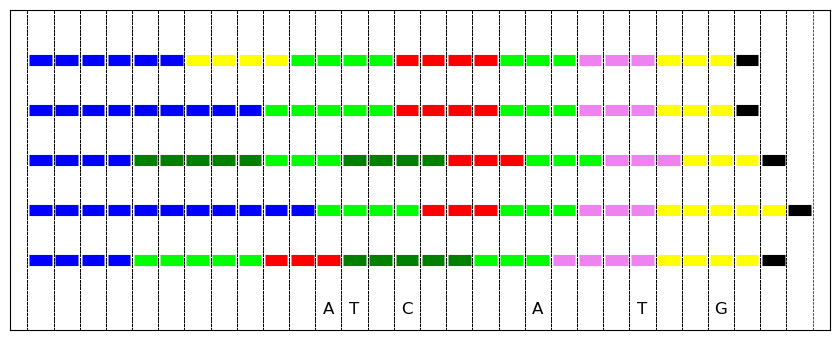

In [32]:
plot_sequences(sample_list, emit_dict, colors)


# Satisifaction Probability Estimation

In [33]:
sat_cst_list = [promoter_cst,stay_cst,pde_cst, hitdis_cst]

In [34]:
probs = satprob_torch_list(end_hmm, sat_cst_list, emit_list, pro_before = 10, dtype = torch.float32,  device = 'cpu', debug = False, num_corr = 0)

In [35]:
B = 500
probsat_cst_list = [promoter_cst,stay_cst, pe_cst, hitdis_cst]
prob_dis = []
for b in range(B):
    state_list, emit_list = simulation(end_hmm, stay=4, pro_before=10, ix_list=None, max_attempts=1000)
    probs = satprob_torch_list(end_hmm, probsat_cst_list, emit_list, pro_before = 10, dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)
    prob_dis.append(probs[0].item())

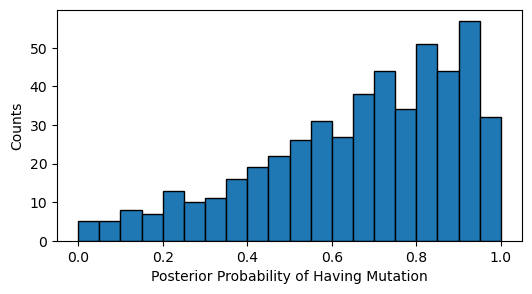

In [36]:
bins = np.linspace(0, 1, 21) 

plt.figure(figsize=(6, 3))

plt.hist(prob_dis, bins=bins, edgecolor='black')

# Adding titles and labels
# plt.title('Histogram of Probabilities')
plt.xlabel('Posterior Probability of Having Mutation')
plt.ylabel('Counts')
plt.savefig('dna_satprob.pdf', format='pdf', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

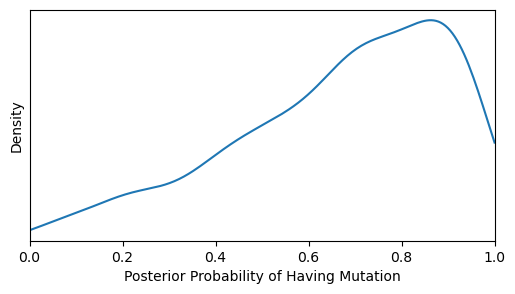

In [37]:
from scipy.stats import gaussian_kde

x = np.linspace(0, 1, 200)
kde = gaussian_kde(prob_dis)

plt.figure(figsize=(6, 3))
plt.plot(x, kde(x))

# plt.title('Distribution of Mutation Probability Estimates (n=500)')
plt.xlabel('Posterior Probability of Having Mutation')
plt.ylabel('Density')
# plt.ylabel('Density')
plt.yticks([])
plt.xlim(0, 1)

plt.savefig('dna_satprob_density.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()


In [38]:
prob_dis = np.array(prob_dis)
print(f'Mean {prob_dis.mean()} Median: {np.median(prob_dis)} SD: {np.std(prob_dis)}')

Mean 0.6654994779191912 Median: 0.7122201919555664 SD: 0.23483653747870906


# Learning with constrained generalized EM

Each sequence has 30 positions, including terminal `N`. Exact FFBS samples the
latent path conditional on the learning constraints; emissions follow the HMM.
GEM maximizes $\sum_i \log p_\theta(y_i,C_T)-n\log p_\theta(C_T)$.
Unconstrained Baum–Welch maximizes $\sum_i \log p_\theta(y_i)$.

Histories include initialization; iteration counts exclude it. Reported counts
include trials that reach the iteration limit. Parameter errors are descriptive:
conditioning can make parameters unidentifiable, including outgoing end transitions.


In [39]:
seed = 23
rng = np.random.default_rng(seed)
num_trials = 25
num_samples = 10
time_horizon = 30  # Includes terminal N.
pro_before = 10
max_iter = 100
tol = 1e-3
inner_max_iter = 10
inner_tol = 1e-6
step_size = 1.0
max_backtracks = 30
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# Correct only the learning constraints; earlier figure experiments are separate.
learning_promoter = copy.deepcopy(promoter_cst)
learning_promoter.eval_fun = lambda k, r: bool(r)
learning_precedence = copy.deepcopy(pde_cst)
learning_precedence.init_fun = lambda k, r: (
    k not in ('dis', 'enh') and r == (k == 'pro', False, False)
)
learning_constraints = [
    learning_promoter, stay_cst, disvisit_cst, learning_precedence, end_cst
]


In [40]:
# --------------------------------------------------
# Helper: convert HMM parameters to aligned numpy arrays
# --------------------------------------------------
def hmm_params_as_arrays(hmm, state_order=None, emit_order=None):
    """
    Convert an HMM object into aligned numpy arrays:
      - init_prob: shape (K,)
      - tmat: shape (K, K)
      - emat: shape (K, M)

    Parameters
    ----------
    hmm : object
        HMM with fields states, emits, initprob, tprob, eprob
    state_order : list or None
        Desired ordering of hidden states
    emit_order : list or None
        Desired ordering of emissions

    Returns
    -------
    init_prob : np.ndarray
    tmat : np.ndarray
    emat : np.ndarray
    """
    if state_order is None:
        state_order = list(hmm.states)
    if emit_order is None:
        emit_order = list(hmm.emits)

    state_ix = {s: i for i, s in enumerate(state_order)}
    emit_ix = {m: i for i, m in enumerate(emit_order)}

    K = len(state_order)
    M = len(emit_order)

    init_prob = np.zeros(K, dtype=np.float64)
    tmat = np.zeros((K, K), dtype=np.float64)
    emat = np.zeros((K, M), dtype=np.float64)

    for s in state_order:
        if s in hmm.initprob:
            init_prob[state_ix[s]] = hmm.initprob[s]

    for s1 in state_order:
        for s2 in state_order:
            if (s1, s2) in hmm.tprob:
                tmat[state_ix[s1], state_ix[s2]] = hmm.tprob[s1, s2]

    for s in state_order:
        for m in emit_order:
            if (s, m) in hmm.eprob:
                emat[state_ix[s], emit_ix[m]] = hmm.eprob[s, m]

    return init_prob, tmat, emat

In [41]:
# --------------------------------------------------
# Ground-truth parameters from end_hmm
# --------------------------------------------------
state_order = list(end_hmm.states)
emit_order = list(end_hmm.emits)

true_init, true_tmat, true_emat = hmm_params_as_arrays(
    end_hmm,
    state_order=state_order,
    emit_order=emit_order
)


# --------------------------------------------------
# Storage
# --------------------------------------------------
constrained_steps = []
unconstrained_steps = []

constrained_terminal_loglik = []
unconstrained_terminal_loglik = []

constrained_histories = []
unconstrained_histories = []

# New: parameter L2 errors
constrained_init_l2 = []
constrained_trans_l2 = []
constrained_emit_l2 = []

unconstrained_init_l2 = []
unconstrained_trans_l2 = []
unconstrained_emit_l2 = []


# --------------------------------------------------
# Repeated experiment
# --------------------------------------------------
for trial in range(num_trials):
    print(f'Currently on trial {trial + 1}')
    
    # Randomly initialize HMM
    hmm_init = randomize_hmm_like(end_hmm, rng=rng, alpha=1.0)
    hmm_init_for_constrained = copy.deepcopy(hmm_init)
    hmm_init_for_unconstrained = copy.deepcopy(hmm_init)
    
    samples = sample_constrained_fixed_length(
        end_hmm, learning_constraints, time_horizon, num_samples,
        pro_before=pro_before, rng=rng, device=device,
    )
    obs_batch = [emits for _, emits in samples]
    print('finished sampling')

    # -----------------------------
    # Constrained training
    # -----------------------------
    hmm_fit_c, hist_c = generalized_em_constrained(
        hmm_init_for_constrained,
        learning_constraints,
        obs_batch,
        pro_before=pro_before,
        max_iter=max_iter,
        tol=tol,
        inner_max_iter=inner_max_iter,
        inner_tol=inner_tol,
        step_size=step_size,
        max_backtracks=max_backtracks,
        verbose=False,
        device=device
    )
    print('finished constrained learning')

    # -----------------------------
    # Unconstrained training
    # -----------------------------
    hmm_fit_u, hist_u = baum_welch_unconstrained(
        hmm_init_for_unconstrained,
        obs_batch,
        max_iter=max_iter,
        tol=tol,
        pseudocount=0.0,
        verbose=False,
        device=device
    )
    print('finished unconstrained learning')

    # Histories / convergence
    constrained_histories.append(hist_c)
    unconstrained_histories.append(hist_u)

    constrained_steps.append(len(hist_c) - 1)
    unconstrained_steps.append(len(hist_u) - 1)

    constrained_terminal_loglik.append(hist_c[-1])
    unconstrained_terminal_loglik.append(hist_u[-1])

    # -----------------------------
    # Parameter error vs ground truth
    # -----------------------------
    fit_c_init, fit_c_tmat, fit_c_emat = hmm_params_as_arrays(
        hmm_fit_c,
        state_order=state_order,
        emit_order=emit_order
    )
    fit_u_init, fit_u_tmat, fit_u_emat = hmm_params_as_arrays(
        hmm_fit_u,
        state_order=state_order,
        emit_order=emit_order
    )

    constrained_init_l2.append(np.linalg.norm(fit_c_init - true_init))
    constrained_trans_l2.append(np.linalg.norm(fit_c_tmat - true_tmat))
    constrained_emit_l2.append(np.linalg.norm(fit_c_emat - true_emat))

    unconstrained_init_l2.append(np.linalg.norm(fit_u_init - true_init))
    unconstrained_trans_l2.append(np.linalg.norm(fit_u_tmat - true_tmat))
    unconstrained_emit_l2.append(np.linalg.norm(fit_u_emat - true_emat))

Currently on trial 1
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 2
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 3
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 4
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 5
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 6
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 7
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 8
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 9
finished sampling
finished constrained learning
finished unconstrained learning
Currently on trial 10
finished sampling
finished constrained learning
finished unconstraine

Constrained GEM: log p(y | C_T)
  Mean completed iterations: 94.080
  Std  completed iterations: 13.833
  Mean terminal log-likelihood: -333.339233
  Std  terminal log-likelihood: 10.067369
  Mean init L2 error: 0.684819
  Std  init L2 error: 0.265109
  Mean trans L2 error: 1.989481
  Std  trans L2 error: 0.230754
  Mean emit L2 error: 1.181755
  Std  emit L2 error: 0.188914

Unconstrained BW: log p(y)
  Mean completed iterations: 97.360
  Std  completed iterations: 7.053
  Mean terminal log-likelihood: -379.755073
  Std  terminal log-likelihood: 9.200287
  Mean init L2 error: 0.965229
  Std  init L2 error: 0.232852
  Mean trans L2 error: 1.843108
  Std  trans L2 error: 0.175997
  Mean emit L2 error: 1.593646
  Std  emit L2 error: 0.229669


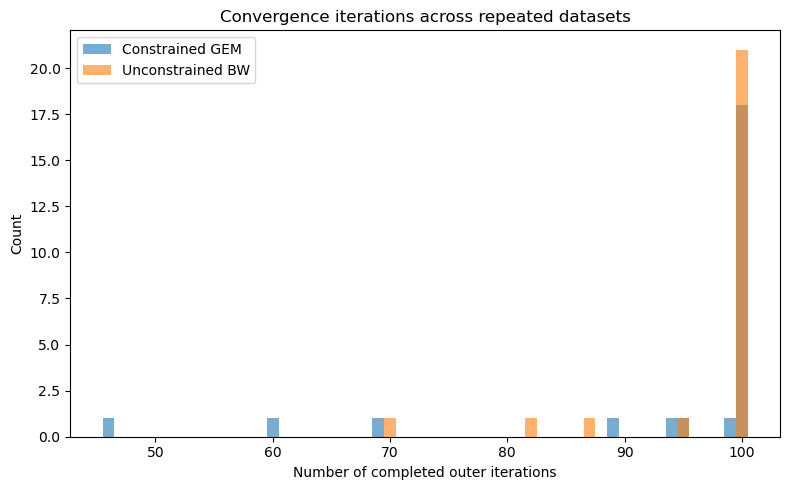

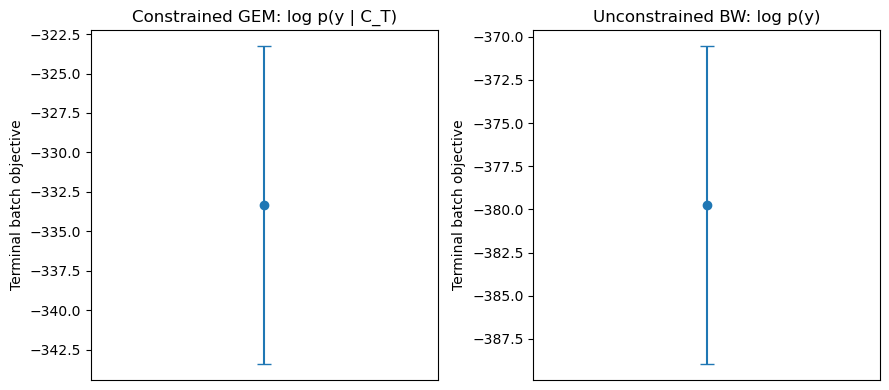

/tmp/ipykernel_7498/576737292.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_7498/576737292.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/tmp/ipykernel_7498/576737292.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


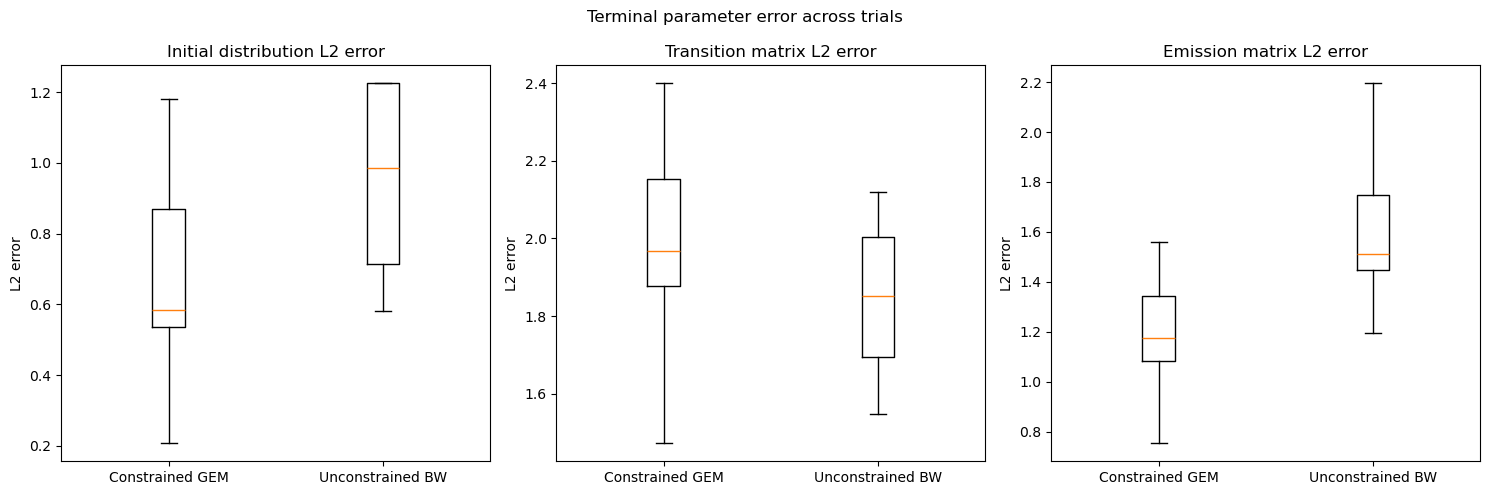

In [42]:
# --------------------------------------------------
# Summary statistics
# --------------------------------------------------
print("Constrained GEM: log p(y | C_T)")
print(f"  Mean completed iterations: {np.mean(constrained_steps):.3f}")
print(f"  Std  completed iterations: {np.std(constrained_steps):.3f}")
print(f"  Mean terminal log-likelihood: {np.mean(constrained_terminal_loglik):.6f}")
print(f"  Std  terminal log-likelihood: {np.std(constrained_terminal_loglik):.6f}")
print(f"  Mean init L2 error: {np.mean(constrained_init_l2):.6f}")
print(f"  Std  init L2 error: {np.std(constrained_init_l2):.6f}")
print(f"  Mean trans L2 error: {np.mean(constrained_trans_l2):.6f}")
print(f"  Std  trans L2 error: {np.std(constrained_trans_l2):.6f}")
print(f"  Mean emit L2 error: {np.mean(constrained_emit_l2):.6f}")
print(f"  Std  emit L2 error: {np.std(constrained_emit_l2):.6f}")

print("\nUnconstrained BW: log p(y)")
print(f"  Mean completed iterations: {np.mean(unconstrained_steps):.3f}")
print(f"  Std  completed iterations: {np.std(unconstrained_steps):.3f}")
print(f"  Mean terminal log-likelihood: {np.mean(unconstrained_terminal_loglik):.6f}")
print(f"  Std  terminal log-likelihood: {np.std(unconstrained_terminal_loglik):.6f}")
print(f"  Mean init L2 error: {np.mean(unconstrained_init_l2):.6f}")
print(f"  Std  init L2 error: {np.std(unconstrained_init_l2):.6f}")
print(f"  Mean trans L2 error: {np.mean(unconstrained_trans_l2):.6f}")
print(f"  Std  trans L2 error: {np.std(unconstrained_trans_l2):.6f}")
print(f"  Mean emit L2 error: {np.mean(unconstrained_emit_l2):.6f}")
print(f"  Std  emit L2 error: {np.std(unconstrained_emit_l2):.6f}")

# --------------------------------------------------
# Histogram: completed iterations
# --------------------------------------------------
bins = np.arange(
    min(min(constrained_steps), min(unconstrained_steps)),
    max(max(constrained_steps), max(unconstrained_steps)) + 2
) - 0.5

plt.figure(figsize=(8, 5))
plt.hist(constrained_steps, bins=bins, alpha=0.6, label='Constrained GEM')
plt.hist(unconstrained_steps, bins=bins, alpha=0.6, label='Unconstrained BW')
plt.xlabel('Number of completed outer iterations')
plt.ylabel('Count')
plt.title('Convergence iterations across repeated datasets')
plt.legend()
plt.tight_layout()
plt.show()

# Separate objectives have separate axes; their magnitudes are not a fit ranking.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, scores, label in zip(
    axes,
    [constrained_terminal_loglik, unconstrained_terminal_loglik],
    ['Constrained GEM: log p(y | C_T)', 'Unconstrained BW: log p(y)'],
):
    ax.errorbar([0], [np.mean(scores)], yerr=[np.std(scores)], fmt='o', capsize=5)
    ax.set_xticks([])
    ax.set_title(label)
    ax.set_ylabel('Terminal batch objective')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Boxplots: parameter L2 errors
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Initial distribution error
axes[0].boxplot(
    [constrained_init_l2, unconstrained_init_l2],
    labels=['Constrained GEM', 'Unconstrained BW']
)
axes[0].set_title('Initial distribution L2 error')
axes[0].set_ylabel('L2 error')

# Transition matrix error
axes[1].boxplot(
    [constrained_trans_l2, unconstrained_trans_l2],
    labels=['Constrained GEM', 'Unconstrained BW']
)
axes[1].set_title('Transition matrix L2 error')
axes[1].set_ylabel('L2 error')

# Emission matrix error
axes[2].boxplot(
    [constrained_emit_l2, unconstrained_emit_l2],
    labels=['Constrained GEM', 'Unconstrained BW']
)
axes[2].set_title('Emission matrix L2 error')
axes[2].set_ylabel('L2 error')

plt.suptitle('Terminal parameter error across trials')
plt.tight_layout()
plt.show()

In [43]:
learning_data = {
    'experiment_version': 'fixed_horizon_gem_v1',
    'objectives': {'constrained': 'sum log p(y | C_T)',
                   'unconstrained': 'sum log p(y)'},
    'settings': dict(seed=seed, num_trials=num_trials, num_samples=num_samples,
                     time_horizon=time_horizon, pro_before=pro_before,
                     max_iter=max_iter, tol=tol, inner_max_iter=inner_max_iter,
                     inner_tol=inner_tol, step_size=step_size,
                     max_backtracks=max_backtracks, dtype='float64', device=device),
    'constrained_steps': constrained_steps, 
        'unconstrained_steps': unconstrained_steps,
        'constrained_terminal_loglik': constrained_terminal_loglik,
       'unconstrained_terminal_loglik': unconstrained_terminal_loglik,
       'constrained_histories': constrained_histories,
       'unconstrained_histories': unconstrained_histories,
        'constrained_init_l2': constrained_init_l2,
        'constrained_trans_l2': constrained_trans_l2,
         'constrained_emit_l2': constrained_emit_l2,
        'unconstrained_init_l2': unconstrained_init_l2,
        'unconstrained_trans_l2': unconstrained_trans_l2,
        'unconstrained_emit_l2': unconstrained_emit_l2
                }

with open("learning_data_gem.json", "w") as f:
    json.dump(learning_data, f, indent=2)

